<a href="https://colab.research.google.com/github/rohit9347/DST-RECORD/blob/main/exp5dst.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Normal Logistic Accuracy: 93.85964912280701
Regularized Logistic Accuracy: 99.12280701754386


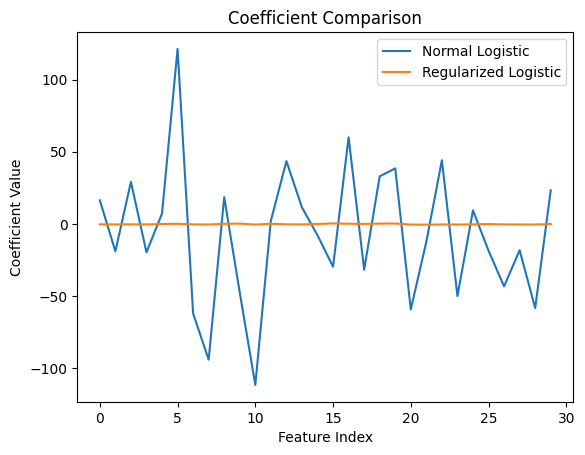

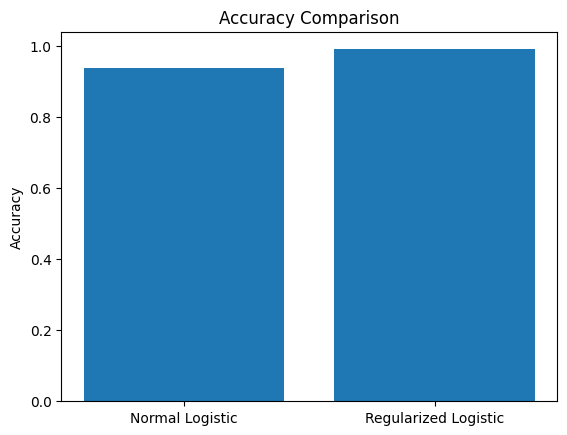

In [ ]:
# Ex No.5: Implement Regularized Logistic Regression

# 1. Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 2. Load Dataset
data = load_breast_cancer()
X = data.data
y = data.target

# 3. Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --------------------------------------------------
# 5. Normal Logistic Regression (Very Large C)
# --------------------------------------------------
normal_model = LogisticRegression(C=1e6, penalty='l2', solver='liblinear')
normal_model.fit(X_train_scaled, y_train)

normal_pred = normal_model.predict(X_test_scaled)
normal_acc = accuracy_score(y_test, normal_pred)

# --------------------------------------------------
# 6. Regularized Logistic Regression
# --------------------------------------------------
regularized_model = LogisticRegression(C=0.1, penalty='l2', solver='liblinear')
regularized_model.fit(X_train_scaled, y_train)

reg_pred = regularized_model.predict(X_test_scaled)
reg_acc = accuracy_score(y_test, reg_pred)

# --------------------------------------------------
# 7. Print Results
# --------------------------------------------------
print("Normal Logistic Accuracy:", normal_acc * 100)
print("Regularized Logistic Accuracy:", reg_acc * 100)

# --------------------------------------------------
# 8. Compare Coefficients
# --------------------------------------------------
plt.figure()
plt.plot(normal_model.coef_.flatten(), label='Normal Logistic')
plt.plot(regularized_model.coef_.flatten(), label='Regularized Logistic')
plt.legend()
plt.title("Coefficient Comparison")
plt.xlabel("Feature Index")
plt.ylabel("Coefficient Value")
plt.show()

# --------------------------------------------------
# 9. Accuracy Comparison Bar Graph
# --------------------------------------------------
plt.figure()
models = ['Normal Logistic', 'Regularized Logistic']
accuracies = [normal_acc, reg_acc]

plt.bar(models, accuracies)
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()